In [1]:
from fastai.vision.all import *

a=9


In [27]:
from google.colab import files as FILE
FILE.upload()
!mv 'kaggle (1) (1).json' kaggle.json

KeyboardInterrupt: 

In [14]:
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [20]:
!cp kaggle.json ~/.kaggle/

In [21]:
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
!kaggle datasets download -d gauravsahani/indian-currency-notes-classifier

Dataset URL: https://www.kaggle.com/datasets/gauravsahani/indian-currency-notes-classifier
License(s): DbCL-1.0
  0% 0.00/20.0M [00:00<?, ?B/s]
100% 20.0M/20.0M [00:00<00:00, 610MB/s]


In [24]:
!unzip indian-currency-notes-classifier.zip

Archive:  indian-currency-notes-classifier.zip
  inflating: Test/1Hundrednote/1.jpg  
  inflating: Test/1Hundrednote/14.jpg  
  inflating: Test/1Hundrednote/15.jpg  
  inflating: Test/1Hundrednote/16.jpg  
  inflating: Test/1Hundrednote/2.jpg  
  inflating: Test/1Hundrednote/3.jpg  
  inflating: Test/2Hundrednote/1.jpg  
  inflating: Test/2Hundrednote/2.jpg  
  inflating: Test/2Hundrednote/3.jpg  
  inflating: Test/2Hundrednote/31.jpg  
  inflating: Test/2Hundrednote/32.jpg  
  inflating: Test/2Hundrednote/33.jpg  
  inflating: Test/2Thousandnote/1.jpg  
  inflating: Test/2Thousandnote/2.jpg  
  inflating: Test/2Thousandnote/3.jpg  
  inflating: Test/2Thousandnote/31.jpg  
  inflating: Test/2Thousandnote/32.jpg  
  inflating: Test/2Thousandnote/33.jpg  
  inflating: Test/5Hundrednote/1.jpg  
  inflating: Test/5Hundrednote/2.jpg  
  inflating: Test/5Hundrednote/3.jpg  
  inflating: Test/5Hundrednote/31.jpg  
  inflating: Test/5Hundrednote/32.jpg  
  inflating: Test/5Hundrednote/33.jpg  

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

import os

In [29]:
plt.style.use("ggplot")
%matplotlib inline

In [30]:
main_train_dir = os.path.join("Train/")
main_test_dir = os.path.join("Test/")

print(main_train_dir)
print(main_test_dir)

Train/
Test/


# FAST AI Resnet

In [32]:
from fastai.vision.all import *

In [31]:
data = ImageDataLoaders.from_folder('',
                                    train='Train',
                                    valid='Test',
                                    bs=16,
                                    seed=42,
                                    item_tfms=Resize(360,method=ResizeMethod.Squish))

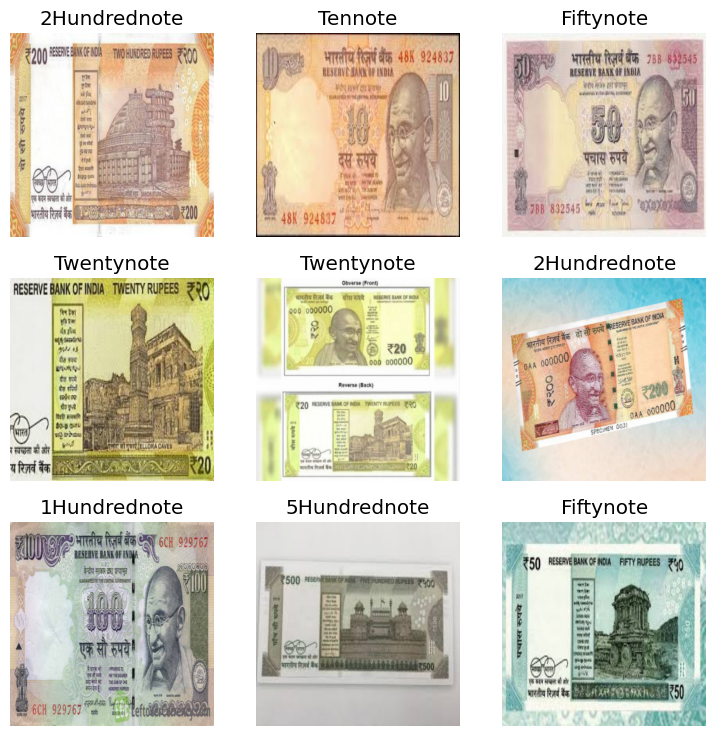

In [33]:
data.show_batch()

In [34]:
learn = cnn_learner(data, resnet34,
                    metrics=[error_rate,accuracy],
                    cbs=[SaveModelCallback()],
                    path='./')

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 133MB/s]


<div></div>

SuggestedLRs(valley=0.002511886414140463)

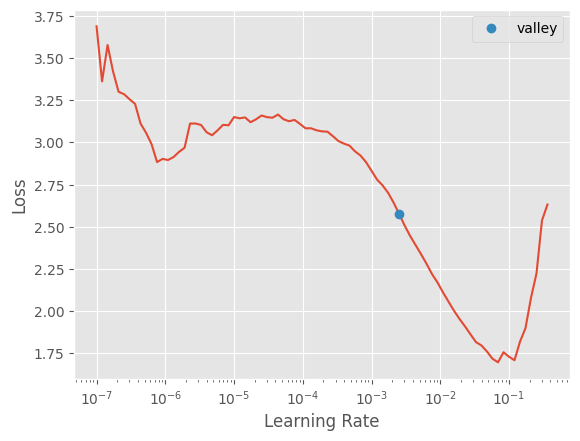

In [35]:
learn.lr_find()

In [36]:
learn.fine_tune(5, 0.001, freeze_epochs=5,cbs=[SaveModelCallback()])

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,3.214553,2.382002,0.857143,0.142857,00:05
1,2.910484,1.611683,0.619048,0.380952,00:02
2,2.392136,0.905309,0.380952,0.619048,00:02
3,1.941508,0.475700,0.190476,0.809524,00:03
4,1.556060,0.298326,0.095238,0.904762,00:02


Better model found at epoch 0 with valid_loss value: 2.382002353668213.
Better model found at epoch 0 with valid_loss value: 2.382002353668213.
Better model found at epoch 1 with valid_loss value: 1.6116831302642822.
Better model found at epoch 1 with valid_loss value: 1.6116831302642822.
Better model found at epoch 2 with valid_loss value: 0.9053086042404175.
Better model found at epoch 2 with valid_loss value: 0.9053086042404175.
Better model found at epoch 3 with valid_loss value: 0.475700318813324.
Better model found at epoch 3 with valid_loss value: 0.475700318813324.
Better model found at epoch 4 with valid_loss value: 0.2983259856700897.
Better model found at epoch 4 with valid_loss value: 0.2983259856700897.


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.262368,0.258655,0.095238,0.904762,00:03
1,0.214538,0.200392,0.047619,0.952381,00:05
2,0.165456,0.169870,0.023810,0.976190,00:03
3,0.157605,0.150084,0.000000,1.000000,00:03
4,0.143018,0.146034,0.000000,1.000000,00:03


Better model found at epoch 0 with valid_loss value: 0.25865450501441956.
Better model found at epoch 0 with valid_loss value: 0.25865450501441956.
Better model found at epoch 1 with valid_loss value: 0.20039232075214386.
Better model found at epoch 1 with valid_loss value: 0.20039232075214386.
Better model found at epoch 2 with valid_loss value: 0.1698702871799469.
Better model found at epoch 2 with valid_loss value: 0.1698702871799469.
Better model found at epoch 3 with valid_loss value: 0.15008415281772614.
Better model found at epoch 3 with valid_loss value: 0.15008415281772614.
Better model found at epoch 4 with valid_loss value: 0.14603359997272491.
Better model found at epoch 4 with valid_loss value: 0.14603359997272491.


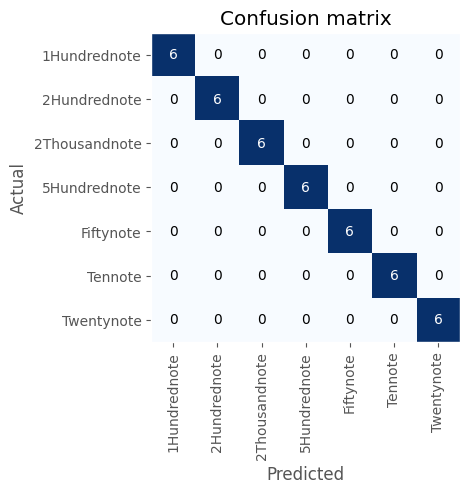

In [37]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

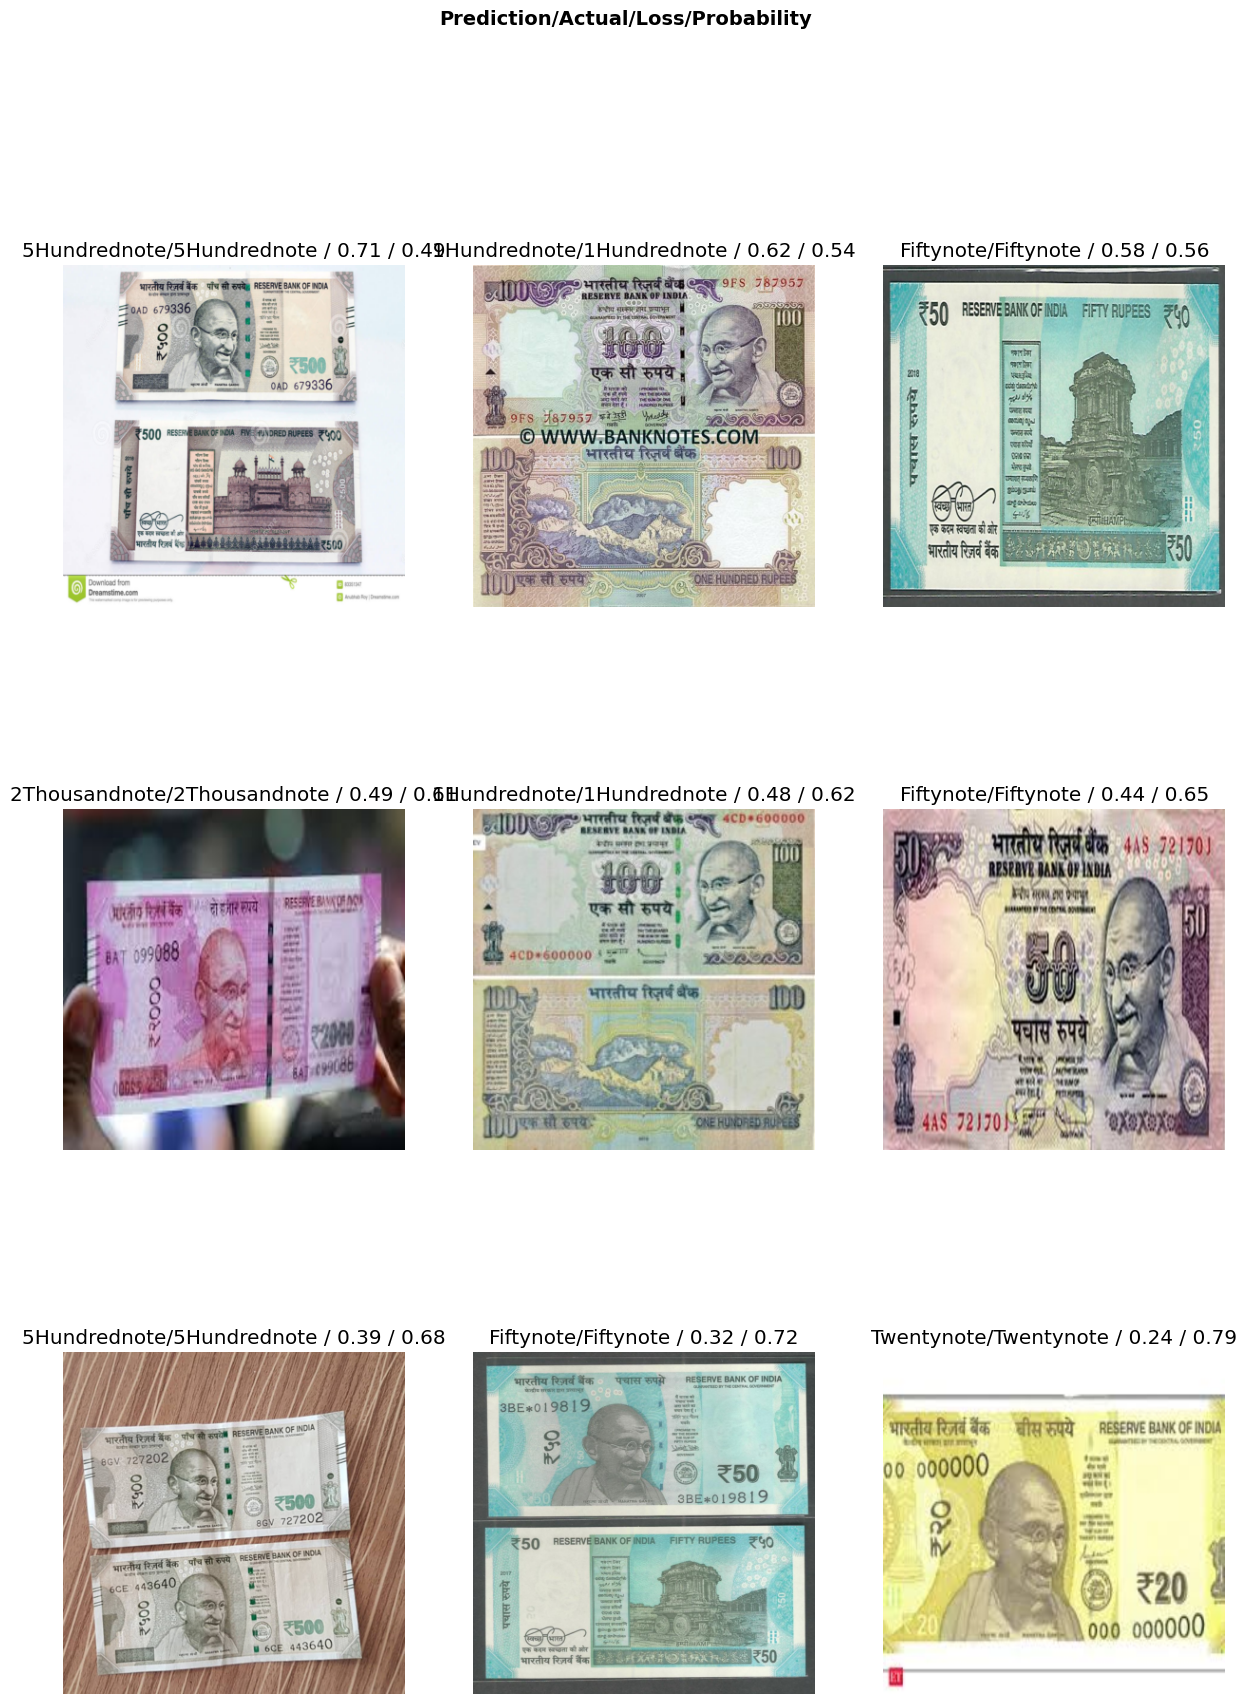

In [38]:
interp.plot_top_losses(9, figsize=(15,20))